In [4]:
import random
import numpy as np
random.seed(42)
np.random.seed(42)

Generate Python code for read

In [5]:
from tensorflow.keras.datasets import mnist, cifar10
import numpy as np

(x_raw, y_raw), (x_test_raw, y_test)= mnist.load_data()

val_size = int(x_raw.shape[0] * 0.3)
rng = np.random.default_rng(42)  # seed for reproducibility
idx = np.arange(x_raw.shape[0])
rng.shuffle(idx)

val_idx = idx[:val_size]
train_idx = idx[val_size:]

(x_train_raw, y_train), (x_val_raw, y_val) = (x_raw[train_idx], y_raw[train_idx]), (x_raw[val_idx], y_raw[val_idx])



import matplotlib.pyplot as plt
import numpy as np
    
x_train, x_test, x_val= x_train_raw/255.0, x_test_raw/255.0, x_val_raw/255.0



In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape = (28,28,1)),
    #1
    layers.Conv2D(filters=16, kernel_size = (3,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    #2
    layers.MaxPooling2D((2,2)),

    #3
    layers.Conv2D(filters=32, kernel_size=(3,3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #4
    layers.MaxPooling2D((2,2)),

    #5
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #6
    layers.Dense(10, activation = "softmax")
])

model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) #Is the loss and metrics correct?
fitted = model.fit(x_train_extra, y_train, epochs = 5, batch_size = 64, validation_data = (x_val_extra, y_val))

test_loss, test_acc = model.evaluate(x_test_extra, y_test)
print("Test accuracy: ", test_acc)

Epoch 1/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.9193 - loss: 0.2601 - val_accuracy: 0.9746 - val_loss: 0.0813
Epoch 2/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9703 - loss: 0.0970 - val_accuracy: 0.9755 - val_loss: 0.0781
Epoch 3/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.9765 - loss: 0.0745 - val_accuracy: 0.9837 - val_loss: 0.0536
Epoch 4/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.9814 - loss: 0.0595 - val_accuracy: 0.9839 - val_loss: 0.0523
Epoch 5/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.9828 - loss: 0.0542 - val_accuracy: 0.9859 - val_loss: 0.0483
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9877 - loss: 0.0380
Test accuracy:  0.9876999855041504


Brute-force black-box attack: One of the most straightforward ways to carry out a 
black-box attack is to use a greedy random search. Here, starting from a correctly 
classified image, one adds salt-and-pepper noise (randomly changing a few 
pixels) step-by-step, until the image is misclassified. More specifically, for a given 
step, after changing the image as just described, one keeps the modified image if 
the probability for the ground truth class 𝐶 is reduced after the modification. If not, 
the previous image is retained, and noise is added again, and so on. Implement 
and run this approach (visualization will follow in Step 5 below) over a few MNIST 
images. 

In [7]:
import random

random.seed(42)

import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
x_test_extra = x_test[..., None]     
x_train_extra = x_train[..., None]  
x_val_extra = x_val[..., None]
pred = 0
actual = np.inf
while pred!= actual:
    picked_index = random.randint(0, len(x_test_extra)-1)

    probs = model(x_test_extra[picked_index:picked_index+1]).numpy()[0]   # x_train[5:6] has shape (1,28,28,1)
    pred = np.argmax(probs)
    
    actual = y_test[picked_index]


1 Pred:  4 Actual:  4 Prob:  0.9999665 Old prob:  0.9999665 

No improvement
2 Pred:  4 Actual:  4 Prob:  0.99996984 Old prob:  0.9999665 

3 Pred:  4 Actual:  4 Prob:  0.9999143 Old prob:  0.9999143 

4 Pred:  4 Actual:  4 Prob:  0.9998541 Old prob:  0.9998541 

No improvement
5 Pred:  4 Actual:  4 Prob:  0.999908 Old prob:  0.9998541 

6 Pred:  4 Actual:  4 Prob:  0.9992532 Old prob:  0.9992532 

No improvement
7 Pred:  4 Actual:  4 Prob:  0.99932826 Old prob:  0.9992532 

8 Pred:  4 Actual:  4 Prob:  0.9974323 Old prob:  0.9974323 

9 Pred:  4 Actual:  4 Prob:  0.99529195 Old prob:  0.99529195 

10 Pred:  4 Actual:  4 Prob:  0.99333936 Old prob:  0.99333936 

11 Pred:  4 Actual:  4 Prob:  0.98164165 Old prob:  0.98164165 

12 Pred:  4 Actual:  4 Prob:  0.92555565 Old prob:  0.92555565 

No improvement
13 Pred:  4 Actual:  4 Prob:  0.9729355 Old prob:  0.92555565 

14 Pred:  4 Actual:  4 Prob:  0.61111337 Old prob:  0.61111337 

15 Pred:  4 Actual:  4 Prob:  0.6109222 Old prob:  0.61

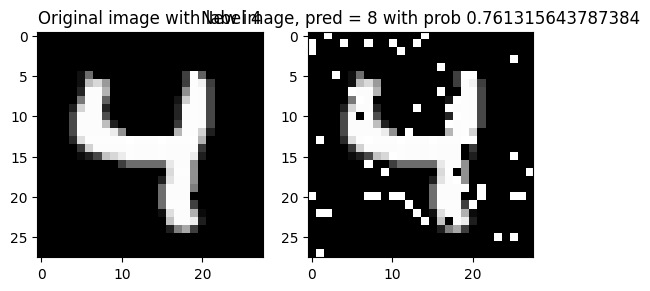

In [15]:
n  = 10

x_original = x_test_extra[picked_index].copy()

def predict(model, image):
    probabilities = model(image, training = False).numpy()[0]
    pred = int(np.argmax(probabilities))
    return pred, probabilities

pred, probs = predict(model, x_test_extra[picked_index:picked_index+1])

old_prob = probs[actual]

step = 0
max_step = 500

pred_new = pred

x_old = x_original.copy()
while pred_new == actual and step < max_step:

    H, W = x_old.shape[0], x_old.shape[1]   # 28, 28
    x_coords = [random.randint(0, W-1) for _ in range(n)]
    y_coords = [random.randint(0, H-1) for _ in range(n)]


    salt_pepper = [random.randint(0, 1) for _ in range(n)]


    x_new = x_old.copy()

    for i in range(n):
        x_new[y_coords[i], x_coords[i], 0] = salt_pepper[i]
    
    pred, probs = predict(model, x_new[None, ...])

    if probs[actual] < old_prob:
        old_prob = probs[actual]
        x_old = x_new.copy()
        pred_new = pred
    else: 
        print("No improvement")

    step += 1
    print(step, "Pred: ", pred, "Actual: ", actual, "Prob: ", probs[actual], "Old prob: ", old_prob, "\n")

final_image = x_old
starting_image = x_original
final_predicted_class = pred_new
final_probability = probs[final_predicted_class]

plt.figure()
plt.subplot(1,2,1)
plt.imshow(x_original[..., 0], cmap = "gray")
plt.title(f"Original image with label {actual}")

plt.subplot(1,2,2)
plt.imshow(x_old[..., 0], cmap = "gray")
plt.title(f"New image, pred = {final_predicted_class} with prob {final_probability}")

plt.show()


Boundary attack
Start with target image T, with ground truth class label C_T and another image I that is classified (label C_I) as something else than the target class
Then tweak I towards T, making it resemble the target
If CNN still classifies that image as C_I -> Successful
Otherwise -> Step rejected, then a smaller step is tried 
Implement and run ovar a few MNIST images

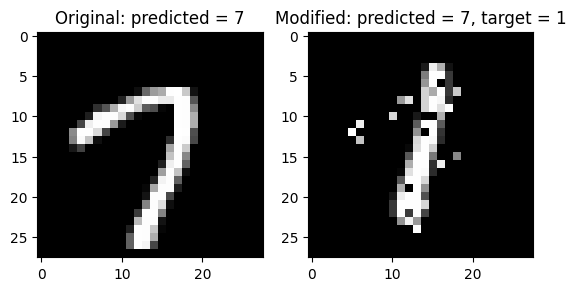

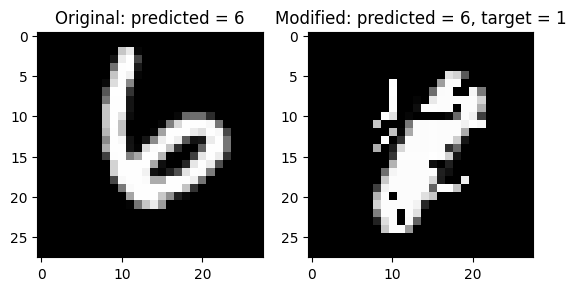

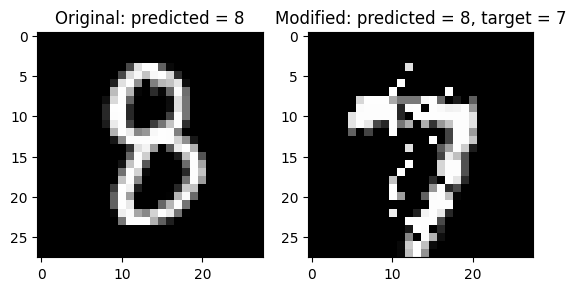

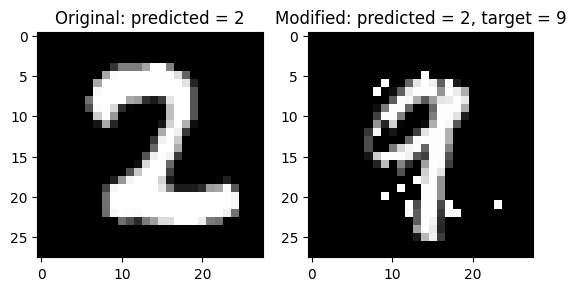

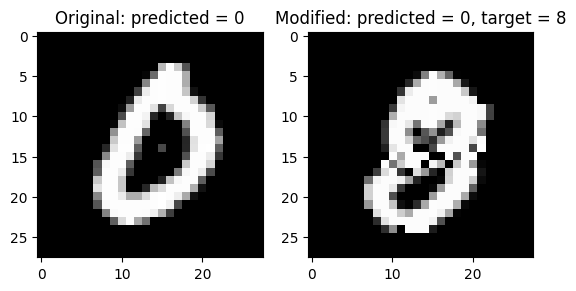

In [ ]:
def boundary_attack(ci_image, target_image, model, ci_predicted, n, max_step = 5000, n_min = 1, n_max = 2000):
    #Tweak image ci towards T

    best_image = ci_image.copy()
    best_pred = ci_predicted
    best_dist = float(np.linalg.norm((best_image - target_image).ravel()))
    best_step = 0
    best_n = n

    current = ci_image.copy()


    for step in range(1, max_step+1):
        if n < n_min:
            break
        x_indx = np.array([random.randint(0, current.shape[1]-1) for _ in range(n)])
        y_indx = np.array([random.randint(0, current.shape[0]-1) for _ in range(n)])

        temporary = current.copy()

        temporary[y_indx, x_indx, 0] = target_image[y_indx, x_indx, 0]


        #If CNN still classifies image as belonging to class C_I
        predicted, probs = predict(model, temporary[None, ...])
        if predicted == ci_predicted:
            #Perturbation was successful
            current = temporary

            dist = np.linalg.norm((temporary-target_image).ravel())

            if dist < best_dist: 
                best_dist = dist
                best_image = current.copy()
                best_pred = predicted
                best_step = step
                best_n = n
        
        else: 
            n = max(n_min, n//2)
        
    return best_image, best_pred, best_dist, best_step, best_n, n





images_num = 5


for i in range(images_num):
    target_found = False
    while target_found == False:
        index = random.randint(0, len(x_test_extra)-1)
        pred, probs = predict(model, x_test_extra[index:index+1])
        if pred == y_test[index]:
            target_found = True

            target_indx = index
            target_actual = y_test[index]
            target_probabilities = probs
            target_image = x_test_extra[target_indx]

    I_found = False
    while I_found == False:
        index = random.randint(0, len(x_test_extra)-1)
        pred, probs = predict(model, x_test_extra[index:index+1])
        if pred != target_actual:
            I_found = True

            ci = index
            ci_predicted = pred
            i_probabilities = probs
            ci_image = x_test_extra[index]


    number_of_pixels_edited = 50



    best_image, best_pred, best_dist, best_step, best_n, n = boundary_attack(ci_image, target_image, model, ci_predicted, number_of_pixels_edited)

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(x_test_extra[ci][..., 0], cmap="gray")
    plt.title(f"Original: predicted = {ci_predicted}")
    plt.subplot(1,2,2)
    plt.imshow(best_image[..., 0], cmap = "gray")
    plt.title(f"Modified: predicted = {best_pred}, target = {target_actual}")
    plt.show()

White box attack
Fast gradietn sign method
Weights of CNN is not changed, but image is modified to maximize lost function (to make CNN as wrong as possible)
Use: x_adv = x + e * sign (\Delta_x J(\theta, x, y))
x= orig image, e = small parameter, J = loss function
gradient is taken with respect to the input pizels (determining which direction to follow in order to maximise error)

In [2]:
import torch
import random

torch.manual_seed(42)

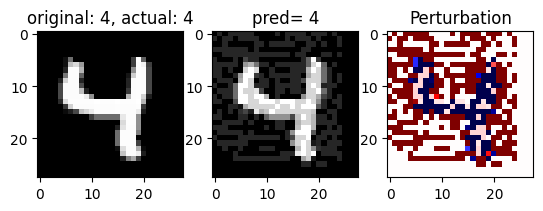

In [13]:
#x_{adv} = x + epsilon * sign(grad)

pred = -1
actual = -2

def predict_tens(model, image):
    probabilities = model(image, training = False).numpy()[0]
    pred = int(np.argmax(probabilities))
    return pred, probabilities


while pred!= actual:
    picked_index = random.randint(0, len(x_test_extra)-1)


    image = x_test_extra[picked_index:picked_index+1]

    probs = model(image, training=False).numpy()[0]   # x_train[5:6] has shape (1,28,28,1)
    pred = np.argmax(probs)
    
    actual = y_test[picked_index]

image = x_test_extra[picked_index:picked_index+1]
image = tf.convert_to_tensor(image, dtype=tf.float32)

loss_func = tf.keras.losses.SparseCategoricalCrossentropy()

def attack(actual, model, image, epsilon):
    tensor_image = tf.convert_to_tensor(image, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(tensor_image)
        prob = model(tensor_image, training=False)
        y_true = tf.convert_to_tensor([int(actual)], dtype=tf.int32)
        loss = loss_func(y_true, prob)

    gradient = tape.gradient(loss, tensor_image)
    sign_grad = tf.sign(gradient)
    #x_{adv} = x + epsilon * sign(grad)
    x_adv = tf.clip_by_value(image + epsilon * sign_grad, 0, 1)

    return x_adv

epsilon = 0.15

x_adv = attack(actual, model, image, epsilon)
pred_adv, probs_adv = predict_tens(model, x_adv)


plt.figure()

plt.subplot(1,3,1)
plt.imshow(image[0, ..., 0], cmap="gray")
plt.title(f"original: {pred}, actual: {actual}")

plt.subplot(1,3,2)
plt.imshow(x_adv[0, ..., 0], cmap="gray")
plt.title(f"pred= {pred_adv}")

plt.subplot(1,3,3)
plt.imshow((x_adv - image)[0, ..., 0], cmap = "seismic")
plt.title("Perturbation")
plt.show()


In [10]:
def greedy_random_search(image, image_and_following, true_label, max_step = 500):
    n  = 10

    x_old = image.copy()

    pred, probs = predict(model, image_and_following)

    old_prob = probs[true_label]

    step = 0

    pred_new = pred


    while pred_new == true_label and step < max_step:

        H, W = x_old.shape[0], x_old.shape[1]   # 28, 28
        x_coords = [random.randint(0, W-1) for _ in range(n)]
        y_coords = [random.randint(0, H-1) for _ in range(n)]


        salt_pepper = [random.randint(0, 1) for _ in range(n)]


        x_new = x_old.copy()

        for i in range(n):
            x_new[y_coords[i], x_coords[i], 0] = salt_pepper[i]
    
        pred, probs = predict(model, x_new[None, ...])

        if probs[true_label] < old_prob:
            old_prob = probs[true_label]
            x_old = x_new.copy()
            pred_new = pred
        else: 
            print("No improvement")

        step += 1
    return x_old



    

In [ ]:




#Find image

target_found = False
while target_found == False:
    index = random.randint(0, len(x_test_extra)-1)
    pred, probs = predict(model, x_test_extra[index:index+1])
    if pred == y_test[index]:
        target_found = True

        target_indx = index
        target_actual = y_test[index]
        target_probabilities = probs
        target_image = x_test_extra[target_indx]

I_found = False
while I_found == False:
    index = random.randint(0, len(x_test_extra)-1)
    pred, probs = predict(model, x_test_extra[index:index+1])
    if pred != target_actual and pred == y_test[index]:
        I_found = True

        ci = index
        ci_predicted = pred
        i_probabilities = probs
        ci_image = x_test_extra[index]
        ci_actual = y_test[ci]


number_of_pixels_edited = 50

target = x_test_extra[target_indx]
target_label = y_test[target_indx]

boundary_image, _, _, _, _, _ = boundary_attack(ci_image, target_image, model, ci_predicted, number_of_pixels_edited)
print("boundary image found")
FSGM_image = attack(target_label, model, target, epsilon)
print("FSGM image found")
greedy_image = greedy_random_search(target, x_test_extra[target_indx: target_indx+1], target_label)
print("Greedy iamge found")

plt.figure()
plt.subplot(1,5,1)
plt.imshow(target, cmap = "gray")
plt.title("Original image")

plt.subplot(1,5,2)
plt.imshow(boundary_image, cmap = "gray")
plt.title("Image created with boundary attack")

plt.subplot(1,5,3)
plt.imshow(greedy_image[..., 0], cmap= "gray")
plt.title("Image generated with random greedy search")

plt.subplot(1,5,4)
plt.imshow(FSGM_image[..., 0], cmap="gray")
plt.title("Image generated with FSGM")

plt.subplot(1,5,5)
plt.imshow(x_test_extra[ci][..., 0], cmap="gray")
plt.title("Image used as target")

plt.show()


NameError: name 'boundary_attack' is not defined